In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

### Problem 1 : Univariate Analysis

Write Python code using NumPy/pandas to:
1. Load the dataset into a DataFrame.


2. Compute the following for the price column:
- Mean
- Median
- Standard Deviation
- 25th and 75th Percentile


3. Plot:
- Histogram of price
- Boxplot of price


4. Identify outliers using the IQR rule.

Answer 2: 

Mean : 65.875
Median : 64.0
Std dev : 15.905412376205241
25th Percentile : 54.25
75th Percentile : 75.25
----------------------------------------------------------------------------------------------------
Answer 3: 



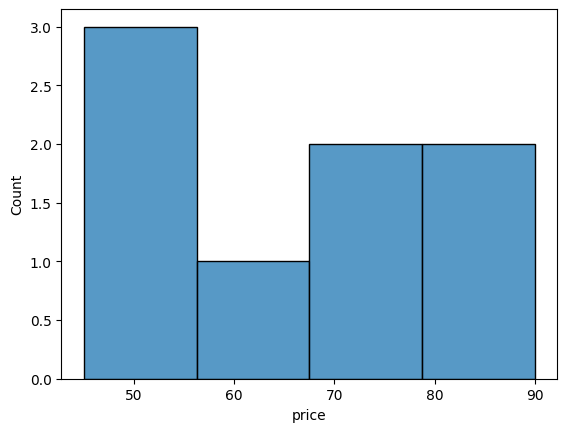

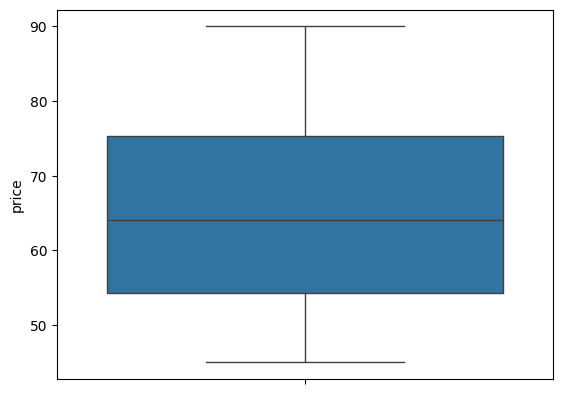

----------------------------------------------------------------------------------------------------
Answer 4: 

Q1:  54.25
Q3:  75.25
IQR : 21.0
lower_bound : 22.75
upper_bound : 106.75
outliers :  []


In [2]:
# 1. Load the dataset into a DataFrame.
df = pd.read_csv(filepath_or_buffer='/content/drive/MyDrive/Colab Notebooks/Datascience Lab 6/house_price.csv')

# 2. Compute the following for the price column
print("Answer 2: \n")
price = df['price']
# Mean
print("Mean :", price.mean())
# Median
print("Median :", price.median())
# Std dev
print("Std dev :", price.std())
# Quantile
print("25th Percentile :", price.quantile(0.25))
print("75th Percentile :", price.quantile(0.75))
print('-'*100)

# 3a. Plot Histogram
print("Answer 3: \n")
sns.histplot(data=price)
plt.show()


# 3b. Plot Boxplot
print('\n')
sns.boxplot(data=price)
plt.show()

# 4. Identify outliers using the IQR rule.
Q1 = price.quantile(0.25)
Q3 = price.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outliers = price[((price < lower_bound) | (price > upper_bound))]


print('-'*100)
print("Answer 4: \n")
print(f"Q1: ", Q1)
print(f"Q3: ", Q3)
print("IQR :", IQR)
print("lower_bound :", lower_bound)
print("upper_bound :", upper_bound)
print("outliers : ", outliers.to_list())

### Problem 2 : Multivariate Analysis
Use the same dataset as above.
Tasks
1. Compute the correlation matrix among:
- price
- area_sqft
- bedrooms
- age
2. Create:
- A heatmap of the correlation matrix
- A scatterplot (area_sqft vs price)
- A pairplot of all numeric variables
3. Interpret:
- Which variable has the strongest positive correlation with price?
- Does age appear to reduce house prices?

Answer 1:
              price  area_sqft  bedrooms       age
price      1.000000   0.997754  0.956529 -0.940522
area_sqft  0.997754   1.000000  0.942535 -0.948822
bedrooms   0.956529   0.942535  1.000000 -0.803685
age       -0.940522  -0.948822 -0.803685  1.000000
----------------------------------------------------------------------------------------------------
Answer 2:


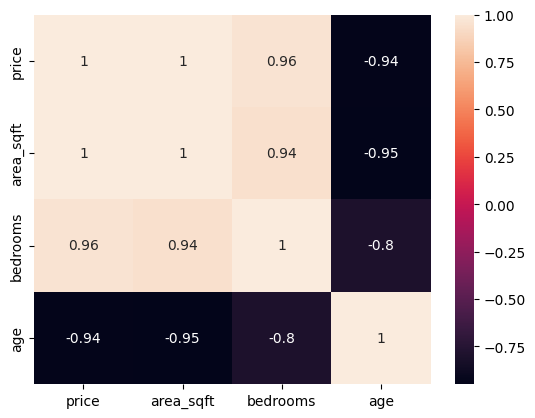

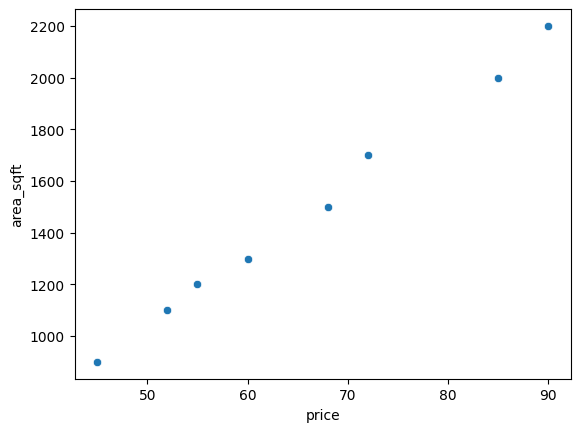

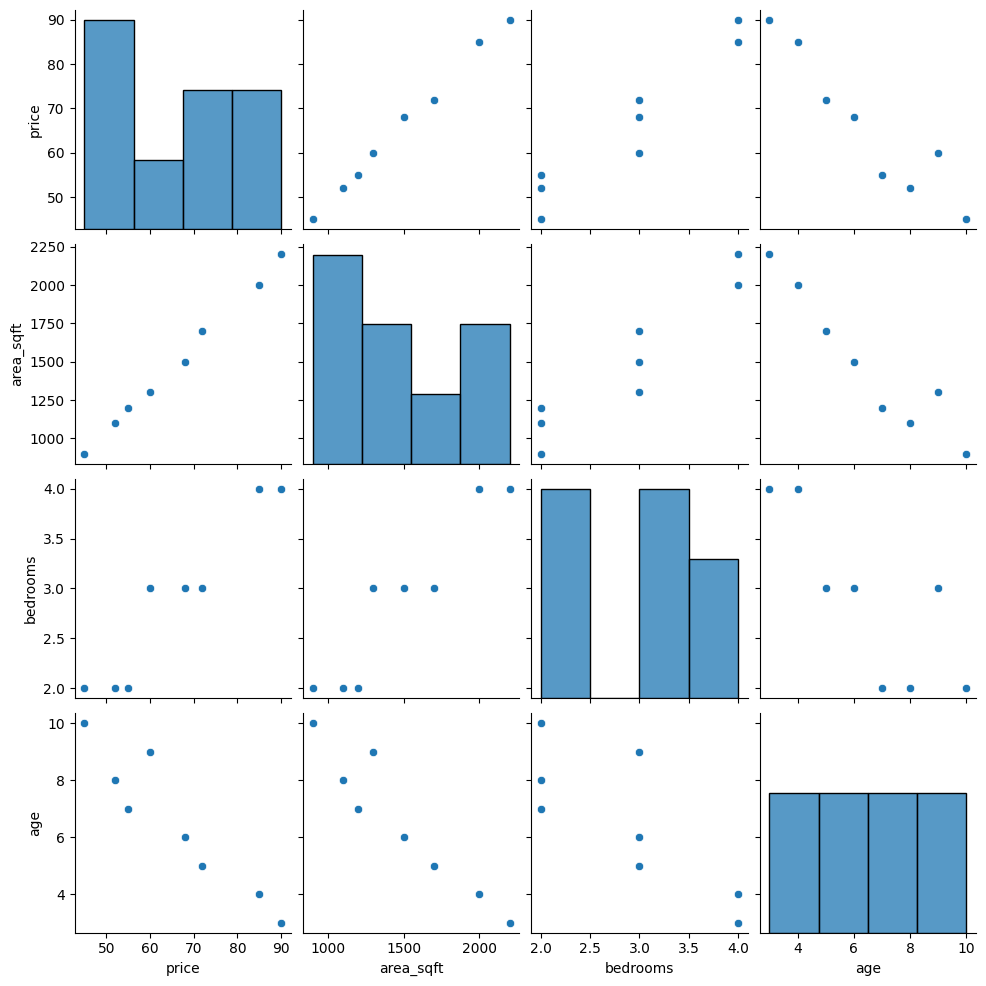

In [3]:
# 1. Compute the correlation matrix among
df_sampled = df[['price', 'area_sqft', 'bedrooms', 'age']]
corr_matrix = df_sampled.corr()
print("Answer 1:")
print(corr_matrix)
print('-'*100)

# 2. A heatmap of the correlation matrix
print("Answer 2:")
sns.heatmap(corr_matrix, annot=True)
plt.show()

print('\n')
sns.scatterplot(data=df, x='price', y='area_sqft')
plt.show()

print('\n')
sns.pairplot(data=df_sampled)
plt.show()

In [4]:
# Interpret:
# 3a. Which variable has the strongest positive correlation with price?
# answer: `Price` has strongest correlation with `area_sqft`


# 3b. Does age appear to reduce house prices?
# answer: By observing both correlation and scatter graph it is evident that with age of the increasing price of house decreases.


### Problem 3 — Linear Regression

Using the same dataset, build a multiple linear regression model predicting:

price ~ area_sqft + bedrooms + age

Tasks
1. Split the dataset into train (70%) and test (30%).
2. Fit a scikit-learn LinearRegression() model.
3. Report:
- Coefficients
- Intercept
4. Evaluate model using:
- MAE
- MSE
- RMSE
- R² score
5. Predict the price for a new house:
- area = 1800 sq ft
- bedrooms = 3
- age = 5 years


In [5]:
# 1. Split the dataset into train (70%) and test (30%).
from sklearn.model_selection import train_test_split

y = df['price']
X = df.drop(columns=['house_id', 'price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=23)

# 2. Fit a scikit-learn LinearRegression() model.
from sklearn.linear_model import LinearRegression

model = LinearRegression()
trained_model = model.fit(X_train, y_train)

# 3. Report: Coefficients, Intercept
print("Answer 3:")
print("Coefficient: ", trained_model.coef_)
print("Intercept: ", trained_model.intercept_)

# 4. Evaluate model using: MAE, MSE, RMSE, R² score
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
y_pred = trained_model.predict(X_test)
print('\n')
print("Answer 4:")
print("mean_absolute_error : %.4f" % mean_absolute_error(y_test, y_pred))
print("mean_squared_error : %.4f" % mean_squared_error(y_test, y_pred))
print("root_mean_squared_error : %.4f" % root_mean_squared_error(y_test, y_pred))
print("r2_scorer : %.4f" % r2_score(y_test, y_pred))

# 5. Predict the price for a new house: area = 1800 sq ft, bedrooms = 3, age = 5 years
X_new = np.array([1800, 3, 5]).reshape(1, -1)
y_val = trained_model.predict(X_new)

print('\n')
print("Answer 5:")
print("predicted price :", y_val)

Answer 3:
Coefficient:  [ 6.42857143e-03  8.21428571e+00 -2.71428571e+00]
Intercept:  49.99999999999994


Answer 4:
mean_absolute_error : 0.9048
mean_squared_error : 1.1224
root_mean_squared_error : 1.0595
r2_scorer : 0.9935


Answer 5:
predicted price : [72.64285714]


### 4. Tasks
1. Perform a univariate analysis on the visits column:
- mean
- std
- plot line graph
2. Perform a bivariate analysis between visits and revenue.
3. Fit a simple linear regression to predict revenue from visits.
4. Predict revenue when visits = 780.

In [6]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datascience Lab 6/month_visits_revenue.csv')
df.head()

,Month,Visits,Revenue_000
0,1,550,80
1,2,610,95
2,3,700,110
3,4,720,115
4,5,750,130


Answer 1: 

Mean : 691.6666666666666
Std dev : 97.45084230865666


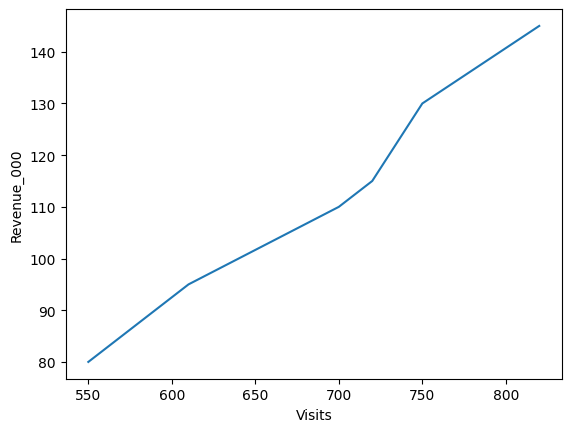

----------------------------------------------------------------------------------------------------
Answer 2: 

Correlation matrix :
               Visits  Revenue_000
Visits       1.000000     0.988938
Revenue_000  0.988938     1.000000




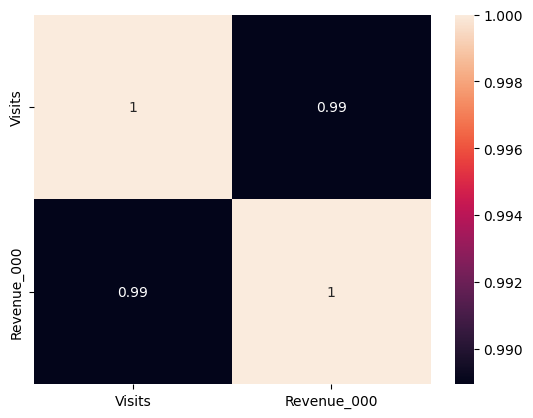

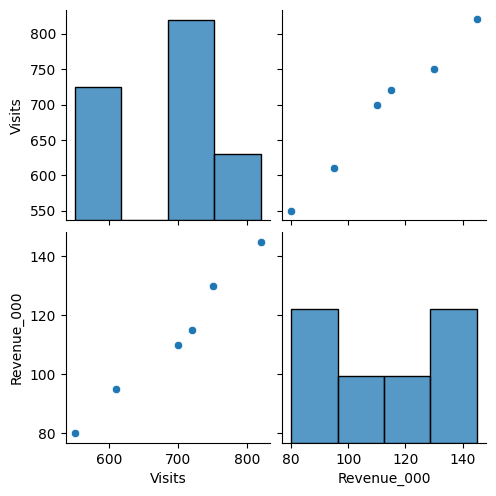

----------------------------------------------------------------------------------------------------
Answer 03: 

Coefficient:  [[0.1984127]]
Intercept:  [-27.97619048]
Y_test :  [145, 130]
Y_pred :  [[134.7222222222222], [120.83333333333331]]
----------------------------------------------------------------------------------------------------
Answer 04: 

predicted revenue : [[126.78571429]]


In [7]:
# 1. Perform a univariate analysis on the visits column:
print("Answer 1: \n")
visits = df['Visits']

# Mean
print("Mean :", visits.mean())
# Std dev
print("Std dev :", visits.std())
# plot line graph
sns.lineplot(data=df, x='Visits', y='Revenue_000')
plt.show()


# 2. Perform a bivariate analysis between visits and revenue.
print('-'*100)
print("Answer 2: \n")
df_sampled = df[['Visits', 'Revenue_000']]

corr_matrix = df_sampled.corr()
print("Correlation matrix :")
print(corr_matrix)

print('\n')
sns.heatmap(corr_matrix, annot=True)
plt.show()

print('\n')
sns.pairplot(data=df_sampled)
plt.show()

# 3. Fit a simple linear regression to predict revenue from visits.
y = df['Revenue_000'].to_frame()
X = df['Visits'].to_frame()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=23)

model = LinearRegression()
trained_model = model.fit(X_train, y_train)

print('-'*100)
print("Answer 03: \n")
print("Coefficient: ", trained_model.coef_)
print("Intercept: ", trained_model.intercept_)

y_pred = trained_model.predict(X_test)
print('Y_test : ', y_test['Revenue_000'].tolist())
print('Y_pred : ', y_pred.tolist())

# 4. Predict revenue when visits = 780.
X_new = np.array([780]).reshape(1, -1)
y_val = trained_model.predict(X_new)

print('-'*100)
print("Answer 04: \n")
print("predicted revenue :", y_val)